# Depth Anything 3 (DA3) Usage Example

This notebook demonstrates how to use Depth Anything 3 for camera poses and depth estimation.


In [1]:
# Install required packages
# !pip install depth-anything-3

# source ~/venv/weeds/bin/activate

# pip install gsplat
# pip install addict

# https://github.com/ByteDance-Seed/Depth-Anything-3/blob/main/da3_streaming/README.md
# https://huggingface.co/depth-anything/DA3-BASE 

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from depth_anything_3.api import DepthAnything3
from depth_anything_3.utils.visualize import visualize_depth
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
model = DepthAnything3.from_pretrained("depth-anything/DA3NESTED-GIANT-LARGE")
#model = DepthAnything3.from_pretrained("depth-anything/da3metric-large")
model = model.to(device)
model.eval()
print(f"Model loaded on {device}")


[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN
Model loaded on cuda


In [3]:
# Run inference on images
images = [
          #"/home/markpp/Desktop/droplet_segmentation/data/iphone/iphone_wet/frame_000110.png", 
          '/home/markpp/DevOps/edge_ml/offline_demo/test_input/wet_crop_0.png',
          #"/home/markpp/Desktop/droplet_segmentation/data/gopro/dough/wet_sequence_3/frame_0133.jpg"
          ]  # List of image paths, PIL Images, or numpy arrays
prediction = model.inference(
    images,
    export_dir="output",
    #infer_gs=True,
    #export_format="gs_video"  # Options: glb, npz, ply, mini_npz, gs_ply, gs_video
    export_format="npz"
)

# Access results
print(prediction.depth.shape)        # Depth maps: [N, H, W] float32
#print(prediction.conf.shape)         # Confidence maps: [N, H, W] float32
#print(prediction.extrinsics.shape)   # Camera poses (w2c): [N, 3, 4] float32
#print(prediction.intrinsics.shape)   # Camera intrinsics: [N, 3, 3] float32

[INFO ] Processed Images Done taking 0.10271954536437988 seconds. Shape:  torch.Size([1, 3, 420, 504])
[INFO ] Model Forward Pass Done. Time: 0.5211398601531982 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0006058216094970703 seconds
[INFO ] Export Results Done. Time: 0.0001678466796875 seconds
(1, 420, 504)


In [ ]:
# Load sample images and run inference
image_paths = [
    "assets/examples/SOH/000.png",
    "assets/examples/SOH/010.png"
]

# Run inference
prediction = model.inference(
    image=image_paths,
    process_res=504,
    process_res_method="upper_bound_resize",
    export_dir=None,
    export_format="glb"
)
print(f"Depth shape: {prediction.depth.shape}")
print(f"Extrinsics: {prediction.extrinsics.shape if prediction.extrinsics is not None else 'None'}")
print(f"Intrinsics: {prediction.intrinsics.shape if prediction.intrinsics is not None else 'None'}")


Depth shape: (2, 280, 504)
Extrinsics: (2, 3, 4)
Intrinsics: (2, 3, 3)


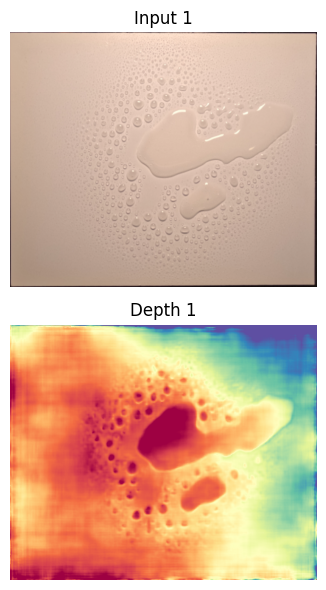

In [4]:
# Visualize input images and depth maps
n_images = prediction.depth.shape[0]

fig, axes = plt.subplots(2, n_images, figsize=(12, 6))

if n_images == 1:
    axes = axes.reshape(2, 1)

for i in range(n_images):
    # Show original image
    if prediction.processed_images is not None:
        axes[0, i].imshow(prediction.processed_images[i])
    axes[0, i].set_title(f"Input {i+1}")
    axes[0, i].axis('off')
    
    # Show depth map
    depth_vis = visualize_depth(prediction.depth[i], cmap="Spectral")
    axes[1, i].imshow(depth_vis)
    axes[1, i].set_title(f"Depth {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()